# DataCo Numerical Exploratory Data Analysis

## 1. Objective and Setup

Explore numerical business measurements and historical shipping performance in the cleaned DataCo dataset. All descriptive results use order-item rows: they are **order-item-weighted**, so orders containing more items receive more weight. Shipping outcomes are used for descriptive EDA only.

Resolve data and figure paths from the repository root using the same logic as the preprocessing notebook. Run this notebook with the working directory set to either the repository root or `notebooks/`.


In [ ]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()


## 2. Load the Cleaned Data

The cleaned dataset contains 180,519 order-item observations and 47 columns, representing 65,752 unique orders.

The unit of analysis is the **order item**, rather than the individual order. Therefore, an `order_id` may appear multiple times when an order contains multiple products or line items. Repeated `order_id` values are expected and should not automatically be interpreted as duplicate observations.

The analysis uses the cleaned dataset generated by the project's existing preprocessing pipeline.

In [ ]:
DATA_PATH = PROJECT_ROOT / "data/processed/dataco_clean.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
print(f"Number of columns: {df.shape[1]}")
print(f"Unique order IDs: {df['order_id'].nunique():,}")


## 3. Identify Numerical Variables

The numerical columns are identified programmatically from the cleaned dataset. Identifier fields may be stored as numbers, but they are structural identifiers rather than meaningful numerical measurements. Therefore, identifiers such as `order_id` should not be treated as ordinary numerical features in the descriptive analysis.

In [4]:
# Identify all numerical columns
numeric_columns = df.select_dtypes(include="number").columns.tolist()

print(f"Number of numerical columns: {len(numeric_columns)}")
print("\nNumerical columns:")

for column in numeric_columns:
    print(column)

Number of numerical columns: 28

Numerical columns:
days_for_shipping_real
days_for_shipment_scheduled
benefit_per_order
sales_per_customer
late_delivery_risk
category_id
customer_id
customer_zipcode
department_id
latitude
longitude
order_customer_id
order_id
order_item_cardprod_id
order_item_discount
order_item_discount_rate
order_item_id
order_item_product_price
order_item_profit_ratio
order_item_quantity
sales
order_item_total
order_profit_per_order
order_zipcode
product_card_id
product_category_id
product_price
product_status


### Numerical Variable Selection

Although 28 columns have numerical data types, not all represent meaningful quantitative measurements. Several columns are identifiers, geographic coordinates, ZIP codes, or categorical codes stored numerically.

For the main numerical descriptive analysis, this notebook focuses on meaningful business and shipping measurements. Identifier and code columns are retained for structural purposes but excluded from standard numerical summary statistics.

In [5]:
analysis_numeric_columns = [
    "days_for_shipping_real",
    "days_for_shipment_scheduled",
    "benefit_per_order",
    "sales_per_customer",
    "order_item_discount",
    "order_item_discount_rate",
    "order_item_product_price",
    "order_item_profit_ratio",
    "order_item_quantity",
    "sales",
    "order_item_total",
    "order_profit_per_order",
    "product_price",
]

print(f"Selected numerical variables: {len(analysis_numeric_columns)}")

for column in analysis_numeric_columns:
    print(column)

Selected numerical variables: 13
days_for_shipping_real
days_for_shipment_scheduled
benefit_per_order
sales_per_customer
order_item_discount
order_item_discount_rate
order_item_product_price
order_item_profit_ratio
order_item_quantity
sales
order_item_total
order_profit_per_order
product_price


## 4. Numerical Summary Statistics

These are **order-item-weighted** results: each row contributes equally, so orders with more items contribute more observations.

The following table summarizes the selected numerical variables. In addition to standard descriptive statistics, missingness, interquartile range (IQR), skewness, and the number of unique values are included to provide a more complete view of each variable's distribution.

Identifier and numerical-code columns are excluded because their numerical values do not represent meaningful quantitative measurements.

In [6]:
summary_stats = pd.DataFrame({
    "count": df[analysis_numeric_columns].count(),
    "missing_count": df[analysis_numeric_columns].isna().sum(),
    "missing_pct": df[analysis_numeric_columns].isna().mean() * 100,
    "mean": df[analysis_numeric_columns].mean(),
    "std": df[analysis_numeric_columns].std(),
    "min": df[analysis_numeric_columns].min(),
    "25%": df[analysis_numeric_columns].quantile(0.25),
    "median": df[analysis_numeric_columns].median(),
    "75%": df[analysis_numeric_columns].quantile(0.75),
    "max": df[analysis_numeric_columns].max(),
    "IQR": (
        df[analysis_numeric_columns].quantile(0.75)
        - df[analysis_numeric_columns].quantile(0.25)
    ),
    "skewness": df[analysis_numeric_columns].skew(),
    "unique_count": df[analysis_numeric_columns].nunique()
})

summary_stats.round(2)

,count,missing_count,missing_pct,mean,std,min,25%,median,75%,max,IQR,skewness,unique_count
days_for_shipping_real,180519,0,0.0,3.50,1.62,0.00,2.00,3.00,5.00,6.00,3.00,0.08,7
days_for_shipment_scheduled,180519,0,0.0,2.93,1.37,0.00,2.00,4.00,4.00,4.00,2.00,-0.73,4
benefit_per_order,180519,0,0.0,21.97,104.43,-4274.98,7.00,31.52,64.80,911.80,57.80,-4.74,21998
sales_per_customer,180519,0,0.0,183.11,120.04,7.49,104.38,163.99,247.40,1939.99,143.02,2.89,2927
order_item_discount,180519,0,0.0,20.66,21.80,0.00,5.40,14.00,29.99,500.00,24.59,3.04,1017
order_item_discount_rate,180519,0,0.0,0.10,0.07,0.00,0.04,0.10,0.16,0.25,0.12,0.34,18
order_item_product_price,180519,0,0.0,141.23,139.73,9.99,50.00,59.99,199.99,1999.99,149.99,3.19,75
order_item_profit_ratio,180519,0,0.0,0.12,0.47,-2.75,0.08,0.27,0.36,0.50,0.28,-2.89,162
order_item_quantity,180519,0,0.0,2.13,1.45,1.00,1.00,1.00,3.00,5.00,2.00,0.88,5
sales,180519,0,0.0,203.77,132.27,9.99,119.98,199.92,299.95,1999.99,179.97,2.88,193


## 5. Target Distribution: Late Delivery Risk

These are **order-item-weighted** results: each row contributes equally, so orders with more items contribute more observations.

The `late_delivery_risk` variable is the target indicator for whether an order item was associated with a late delivery. Its distribution is examined to understand the balance between late and non-late delivery observations before comparing numerical variables across delivery outcomes.

In [7]:
target_counts = df["late_delivery_risk"].value_counts().sort_index()

target_distribution = pd.DataFrame({
    "count": target_counts,
    "percentage": (target_counts / len(df)) * 100
})

target_distribution.index = target_distribution.index.map({
    0: "Not Late (0)",
    1: "Late (1)"
})

target_distribution.round(2)

,count,percentage
late_delivery_risk,,
Not Late (0),81542,45.17
Late (1),98977,54.83


### Interpretation

The following interpretation describes **order-item-weighted** results.

Late deliveries account for 54.83% of the observations, while 45.17% are classified as not late. Therefore, late deliveries are somewhat more common in this dataset.

The target distribution is relatively balanced, although there is a modest majority of late-delivery observations. This distribution provides useful context for later comparisons of numerical variables between late and non-late delivery groups.

## 6. Shipping Duration Analysis

These are **order-item-weighted** results: each row contributes equally, so orders with more items contribute more observations.

Shipping performance is examined using `days_for_shipping_real` and `days_for_shipment_scheduled`.

For descriptive EDA, a shipping delay variable is derived as:

**shipping_delay_days = actual shipping days - scheduled shipping days**

A positive value indicates that actual shipping took longer than scheduled, zero indicates that actual and scheduled durations were equal, and a negative value indicates that actual shipping was faster than scheduled.

This derived variable is used only for descriptive analysis. Because it depends on the actual shipping duration, it contains post-outcome information and must not be used as an order-time predictive feature.

In [8]:
# Derive shipping delay for descriptive EDA only
df["shipping_delay_days"] = (
    df["days_for_shipping_real"]
    - df["days_for_shipment_scheduled"]
)

shipping_delay_summary = df[
    [
        "days_for_shipping_real",
        "days_for_shipment_scheduled",
        "shipping_delay_days"
    ]
].describe().T

shipping_delay_summary.round(2)

,count,mean,std,min,25%,50%,75%,max
days_for_shipping_real,180519.0,3.50,1.62,0.0,2.0,3.0,5.0,6.0
days_for_shipment_scheduled,180519.0,2.93,1.37,0.0,2.0,4.0,4.0,4.0
shipping_delay_days,180519.0,0.57,1.49,-2.0,0.0,1.0,1.0,4.0


In [9]:
delay_counts = pd.Series({
    "Late (positive delay)": (df["shipping_delay_days"] > 0).sum(),
    "On schedule (zero delay)": (df["shipping_delay_days"] == 0).sum(),
    "Early (negative delay)": (df["shipping_delay_days"] < 0).sum()
})

delay_distribution = pd.DataFrame({
    "count": delay_counts,
    "percentage": (delay_counts / len(df)) * 100
})

delay_distribution.round(2)

,count,percentage
Late (positive delay),103400,57.28
On schedule (zero delay),33753,18.70
Early (negative delay),43366,24.02


### Shipping Duration Interpretation

The following interpretation describes **order-item-weighted** results.

Actual shipping takes an average of 3.50 days, compared with an average scheduled shipping duration of 2.93 days. The derived `shipping_delay_days` variable has a mean of 0.57 days and a median of 1 day.

Based on the difference between actual and scheduled shipping duration:

- 57.28% of observations have a positive shipping delay, meaning actual shipping took longer than scheduled.
- 18.70% have zero delay, meaning actual and scheduled shipping durations were equal.
- 24.02% have a negative delay, meaning actual shipping was faster than scheduled.

These results show that positive shipping delays are the most common of the three categories in this dataset. However, these patterns are descriptive and should not be interpreted as evidence that any particular variable causes late delivery.

`shipping_delay_days` is a post-outcome variable because it uses actual shipping duration. It is appropriate for descriptive EDA but should not be used as an order-time predictive feature.

### Unique-Order Shipping Comparison

Before giving each order equal weight, check that actual and scheduled shipping durations are identical across all items within each `order_id`, including missing values in the consistency check. If either field differs within an order, do not arbitrarily select a row. The comparison also requires complete order IDs and shipping durations. `order_id` is used only as a structural/grouping identifier.


In [ ]:
# Verify order-level consistency before selecting one representative per order.
shipping_columns = ["days_for_shipping_real", "days_for_shipment_scheduled"]
shipping_values_per_order = df.groupby("order_id")[shipping_columns].nunique(dropna=False)
inconsistent_shipping_orders = shipping_values_per_order.gt(1).any(axis=1)
missing_order_ids = int(df["order_id"].isna().sum())
missing_shipping_values = int(df[shipping_columns].isna().sum().sum())

print(f"Unique orders: {df['order_id'].nunique():,}")
print(f"Orders with inconsistent shipping values: {inconsistent_shipping_orders.sum():,}")
print(f"Missing order IDs: {missing_order_ids:,}")
print(f"Missing shipping values: {missing_shipping_values:,}")

if inconsistent_shipping_orders.any() or missing_order_ids or missing_shipping_values:
    print("Unique-order comparison omitted: shipping values must be consistent and complete within identified orders.")
else:
    # Selecting a row is valid only after confirming identical shipping values.
    order_shipping = df[["order_id"] + shipping_columns].drop_duplicates("order_id").copy()
    order_shipping["shipping_delay_days"] = (
        order_shipping["days_for_shipping_real"]
        - order_shipping["days_for_shipment_scheduled"]
    )
    order_shipping_summary = order_shipping[
        shipping_columns + ["shipping_delay_days"]
    ].describe().T
    print("\nUnique-order shipping summary (each order has equal weight):")
    print(order_shipping_summary.round(2).to_string())

    def shipping_delay_percentages(delays):
        return pd.Series({
            "Late (positive delay)": delays.gt(0).mean() * 100,
            "On schedule (zero delay)": delays.eq(0).mean() * 100,
            "Early (negative delay)": delays.lt(0).mean() * 100,
        })

    order_delay_comparison = pd.DataFrame({
        "Order-item-weighted (%)": shipping_delay_percentages(df["shipping_delay_days"]),
        "Unique-order (%)": shipping_delay_percentages(order_shipping["shipping_delay_days"]),
    })
    order_delay_comparison["Difference (percentage points)"] = (
        order_delay_comparison["Unique-order (%)"]
        - order_delay_comparison["Order-item-weighted (%)"]
    )
    print("\nShipping delay percentages by unit of analysis:")
    print(order_delay_comparison.round(2).to_string())


Unique orders: 65,752
Orders with inconsistent shipping values: 0
Missing order IDs: 0
Missing shipping values: 0

Unique-order shipping summary (each order has equal weight):
                               count  mean   std  min  25%  50%  75%  max
days_for_shipping_real       65752.0  3.50  1.62  0.0  2.0  3.0  5.0  6.0
days_for_shipment_scheduled  65752.0  2.93  1.37  0.0  2.0  4.0  4.0  4.0
shipping_delay_days          65752.0  0.57  1.49 -2.0  0.0  1.0  1.0  4.0

Shipping delay percentages by unit of analysis:
                          Order-item-weighted (%)  Unique-order (%)  Difference (percentage points)
Late (positive delay)                       57.28             57.33                            0.05
On schedule (zero delay)                    18.70             18.66                           -0.04
Early (negative delay)                      24.02             24.01                           -0.01


### Unique-Order Comparison Interpretation

In the existing cleaned dataset, both shipping fields are consistent within all **65,752 unique orders**, with no missing order IDs or shipping values. Selecting one representative row per order therefore preserves the verified shipping measurements.

With each order weighted equally, actual shipping duration averages **3.50 days**, scheduled duration averages **2.93 days**, and shipping delay averages **0.57 days**. The medians are 3, 4, and 1 day, respectively. Positive, zero, and negative delays account for **57.33%**, **18.66%**, and **24.01%** of unique orders, compared with **57.28%**, **18.70%**, and **24.02%** of order-item rows. The rounded means match, and delay-category differences are less than 0.06 percentage points. The overall descriptive conclusion is similar under both weighting approaches.

Actual shipping duration and derived shipping delay remain post-outcome, EDA-only measures. This comparison does not establish causation. These figures describe the current cleaned dataset; rerun the consistency check before interpreting a changed dataset.


In [ ]:
FIGURE_DIR = PROJECT_ROOT / "reports/figures/numerical"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Figures will be saved to: {FIGURE_DIR.relative_to(PROJECT_ROOT)}")


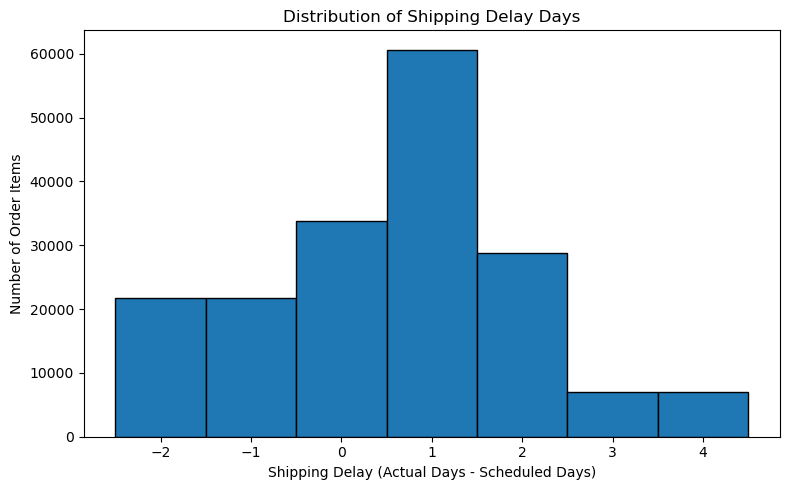

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    df["shipping_delay_days"],
    bins=range(
        int(df["shipping_delay_days"].min()),
        int(df["shipping_delay_days"].max()) + 2
    ),
    edgecolor="black",
    align="left"
)

plt.title("Distribution of Shipping Delay Days")
plt.xlabel("Shipping Delay (Actual Days - Scheduled Days)")
plt.ylabel("Number of Order Items")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "shipping_delay_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Shipping Delay Distribution

The following interpretation describes **order-item-weighted** results.

The shipping delay distribution ranges from -2 to 4 days. A delay of 1 day is the most frequently observed value.

Negative values represent shipments completed faster than scheduled, while positive values represent shipments that took longer than scheduled. Consistent with the earlier delay-category analysis, the distribution contains more observations with positive delays than with negative delays.

Because `shipping_delay_days` is calculated using actual shipping duration, this variable is used only for descriptive EDA and not as an order-time predictive feature.

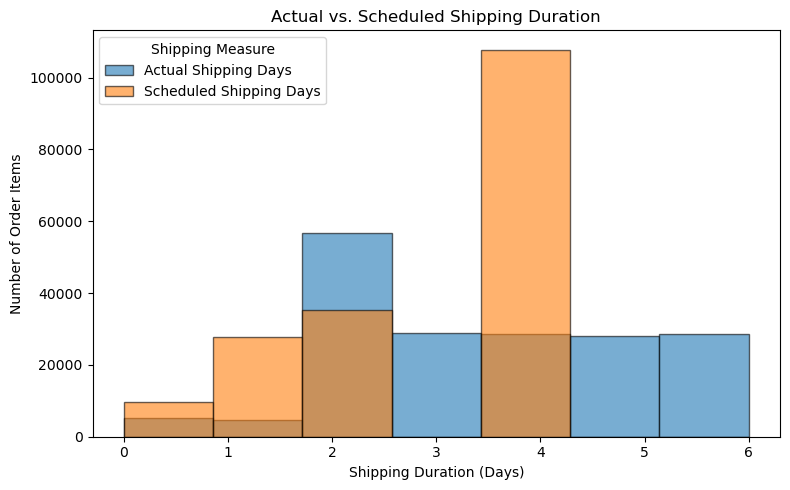

In [12]:
shipping_comparison = df[
    ["days_for_shipping_real", "days_for_shipment_scheduled"]
].rename(columns={
    "days_for_shipping_real": "Actual Shipping Days",
    "days_for_shipment_scheduled": "Scheduled Shipping Days"
})

shipping_comparison.plot(
    kind="hist",
    bins=7,
    alpha=0.6,
    figsize=(8, 5),
    edgecolor="black"
)

plt.title("Actual vs. Scheduled Shipping Duration")
plt.xlabel("Shipping Duration (Days)")
plt.ylabel("Number of Order Items")
plt.legend(title="Shipping Measure")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "actual_vs_scheduled_shipping.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Actual vs. Scheduled Shipping Duration

The following interpretation describes **order-item-weighted** results.

Scheduled shipping durations are concentrated at a smaller number of values, with 4 days appearing especially frequently. In contrast, actual shipping durations are distributed more broadly across the observed range.

The broader distribution of actual shipping times indicates that realized shipping duration varies more than the scheduled duration. This is consistent with the earlier finding that 57.28% of observations have a positive shipping delay.

These results describe an association between scheduled and realized shipping performance and do not establish a causal relationship.

## 7. Numerical Variables by Delivery Outcome

These are **order-item-weighted** results: each row contributes equally, so orders with more items contribute more observations.

To explore how numerical characteristics differ across delivery outcomes, selected numerical variables are summarized separately for late and non-late observations.

These comparisons are descriptive. Differences between the groups represent associations in the observed data and should not be interpreted as evidence that a numerical variable causes late delivery.

In [13]:
outcome_comparison = (
    df.groupby("late_delivery_risk")[analysis_numeric_columns]
    .agg(["count", "mean", "median", "std"])
    .T
)

outcome_comparison.columns = ["Not Late (0)", "Late (1)"]

outcome_comparison.round(2)

Not Late (0)  Late (1)
days_for_shipping_real      count       81542.00  98977.00
                            mean            2.78      4.09
                            median          3.00      5.00
                            std             1.16      1.71
days_for_shipment_scheduled count       81542.00  98977.00
                            mean            3.49      2.47
                            median          4.00      2.00
                            std             1.15      1.37
benefit_per_order           count       81542.00  98977.00
                            mean           22.40     21.62
                            median         31.68     31.43
                            std           103.16    105.47
sales_per_customer          count       81542.00  98977.00
                            mean          183.61    182.69
                            median        163.99    163.99
                            std           121.43    118.89
order_item_discount         count       81542.00  98977.00
                            mean           20.68     20.65
                            median         14.04     14.00
                            std            21.94     21.69
order_item_discount_rate    count       81542.00  98977.00
                            mean            0.10      0.10
                            median          0.10      0.09
                            std             0.07      0.07
order_item_product_price    count       81542.00  98977.00
                            mean          141.57    140.96
                            median         65.00     59.99
                            std           141.27    138.46
order_item_profit_ratio     count       81542.00  98977.00
                            mean            0.12      0.12
                            median          0.27      0.27
                            std             0.46      0.47
order_item_quantity         count       81542.00  98977.00
                            mean            2.13      2.13
                            median          1.00      1.00
                            std             1.45      1.45
sales                       count       81542.00  98977.00
                            mean          204.29    203.34
                            median        199.92    199.92
                            std           133.81    130.99
order_item_total            count       81542.00  98977.00
                            mean          183.61    182.69
                            median        163.99    163.99
                            std           121.43    118.89
order_profit_per_order      count       81542.00  98977.00
                            mean           22.40     21.62
                            median         31.68     31.43
                            std           103.16    105.47
product_price               count       81542.00  98977.00
                            mean          141.57    140.96
                            median         65.00     59.99
                            std           141.27    138.46

### Delivery Outcome Comparison

The following interpretation describes **order-item-weighted** results.

The largest descriptive differences between late and non-late observations occur in the shipping-duration variables.

Late observations have an average actual shipping duration of 4.09 days, compared with 2.78 days for non-late observations. The median actual shipping duration is also higher for late observations (5 days) than for non-late observations (3 days).

Scheduled shipping duration shows a different pattern. Late observations have an average scheduled duration of 2.47 days, compared with 3.49 days for non-late observations. This suggests an association between tighter scheduled shipping times and the observed late-delivery classification.

In contrast, the financial and order-item variables show relatively small differences between the two delivery groups. Mean sales, quantity, discounts, product prices, and profit measures are similar across late and non-late observations.

These comparisons are descriptive and do not establish causation. In particular, `days_for_shipping_real` contains post-outcome information and is examined for EDA purposes only rather than as an order-time predictive feature.

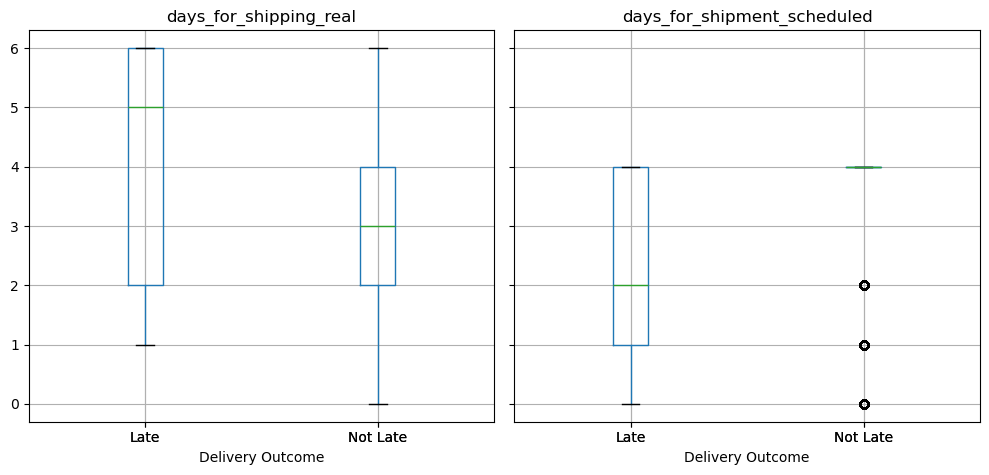

In [14]:
comparison_plot_data = df[
    [
        "late_delivery_risk",
        "days_for_shipping_real",
        "days_for_shipment_scheduled"
    ]
].copy()

comparison_plot_data["Delivery Outcome"] = comparison_plot_data[
    "late_delivery_risk"
].map({
    0: "Not Late",
    1: "Late"
})

comparison_plot_data.boxplot(
    column=[
        "days_for_shipping_real",
        "days_for_shipment_scheduled"
    ],
    by="Delivery Outcome",
    figsize=(10, 5)
)

plt.suptitle("")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "late_delivery_numeric_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Shipping Duration by Delivery Outcome

The following interpretation describes **order-item-weighted** results.

The boxplots show clear descriptive differences in shipping duration between late and non-late observations.

Late observations generally have longer actual shipping durations, with a median of 5 days compared with 3 days for non-late observations. In contrast, scheduled shipping duration tends to be shorter for late observations, with a median of 2 days compared with 4 days for non-late observations.

The scheduled-duration boxplot also identifies some lower scheduled durations among the non-late observations as statistical outliers. These observations are retained because being identified by a boxplot or IQR rule does not by itself indicate that the values are invalid.

These patterns represent associations with delivery outcome and should not be interpreted as causal relationships. Actual shipping duration is also post-outcome information and is used here only for descriptive EDA.

## 8. Sales, Quantity, and Financial Variables

This section examines the distributions and ranges of numerical variables related to sales, quantity, discounts, prices, and profitability.

The analysis considers skewness, extreme values, potentially suspicious values, and possible redundancy between variables. Extreme observations are not automatically removed because unusual values may still represent legitimate transactions.

In [15]:
financial_columns = [
    "benefit_per_order",
    "sales_per_customer",
    "order_item_discount",
    "order_item_discount_rate",
    "order_item_product_price",
    "order_item_profit_ratio",
    "order_item_quantity",
    "sales",
    "order_item_total",
    "order_profit_per_order",
    "product_price"
]

financial_review = pd.DataFrame({
    "min": df[financial_columns].min(),
    "median": df[financial_columns].median(),
    "mean": df[financial_columns].mean(),
    "max": df[financial_columns].max(),
    "skewness": df[financial_columns].skew(),
    "unique_count": df[financial_columns].nunique()
})

financial_review.round(2)

,min,median,mean,max,skewness,unique_count
benefit_per_order,-4274.98,31.52,21.97,911.80,-4.74,21998
sales_per_customer,7.49,163.99,183.11,1939.99,2.89,2927
order_item_discount,0.00,14.00,20.66,500.00,3.04,1017
order_item_discount_rate,0.00,0.10,0.10,0.25,0.34,18
order_item_product_price,9.99,59.99,141.23,1999.99,3.19,75
order_item_profit_ratio,-2.75,0.27,0.12,0.50,-2.89,162
order_item_quantity,1.00,1.00,2.13,5.00,0.88,5
sales,9.99,199.92,203.77,1999.99,2.88,193
order_item_total,7.49,163.99,183.11,1939.99,2.89,2927
order_profit_per_order,-4274.98,31.52,21.97,911.80,-4.74,21998


### Financial Variable Interpretation

Several financial variables show substantial skewness and wide ranges.

`benefit_per_order` and `order_profit_per_order` are strongly negatively skewed (-4.74) and range from -4274.98 to 911.80. The negative values indicate that some observations are associated with losses rather than profits. Similarly, `order_item_profit_ratio` includes negative values and is negatively skewed (-2.89).

Sales- and price-related variables are positively skewed. `sales`, `sales_per_customer`, `order_item_product_price`, and `product_price` contain relatively large upper-end values compared with their medians. `order_item_discount` is also positively skewed, with values ranging from 0 to 500.

`order_item_quantity` has a relatively limited range of 1 to 5 units and shows less extreme skewness than most financial variables.

Some variables have identical descriptive statistics. In particular, `benefit_per_order` and `order_profit_per_order`, `sales_per_customer` and `order_item_total`, and `order_item_product_price` and `product_price` appear potentially redundant. Their relationships will be examined further in the correlation analysis.

Extreme values are retained at this stage because unusual observations are not necessarily invalid. No observations are removed solely because of their magnitude or skewness.

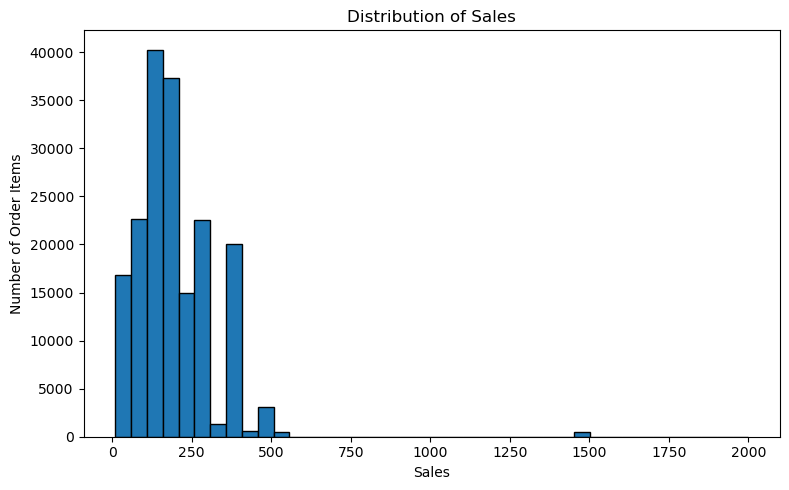

In [16]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["sales"],
    bins=40,
    edgecolor="black"
)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Number of Order Items")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "sales_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 9. Correlation Analysis

These are **order-item-weighted** results: each row contributes equally, so orders with more items contribute more observations.

Correlation analysis is used to examine relationships among selected meaningful numerical variables. Identifier fields, ZIP codes, and numerical category codes are excluded because their numerical values do not represent continuous quantitative measurements.

Post-outcome variables such as actual shipping duration may be included for descriptive purposes, but their correlations should not be interpreted as evidence that they are appropriate predictive features. Correlation also measures association rather than causation.

In [17]:
correlation_columns = [
    "days_for_shipping_real",
    "days_for_shipment_scheduled",
    "benefit_per_order",
    "sales_per_customer",
    "order_item_discount",
    "order_item_discount_rate",
    "order_item_product_price",
    "order_item_profit_ratio",
    "order_item_quantity",
    "sales",
    "order_item_total",
    "order_profit_per_order",
    "product_price",
    "late_delivery_risk"
]

correlation_matrix = df[correlation_columns].corr()

correlation_matrix.round(2)

,days_for_shipping_real,days_for_shipment_scheduled,benefit_per_order,sales_per_customer,order_item_discount,order_item_discount_rate,order_item_product_price,order_item_profit_ratio,order_item_quantity,sales,order_item_total,order_profit_per_order,product_price,late_delivery_risk
days_for_shipping_real,1.00,0.52,-0.01,0.00,0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,-0.01,0.00,0.40
days_for_shipment_scheduled,0.52,1.00,-0.00,0.01,0.00,0.00,0.01,-0.00,-0.00,0.01,0.01,-0.00,0.01,-0.37
benefit_per_order,-0.01,-0.00,1.00,0.13,0.06,-0.02,0.10,0.82,0.02,0.13,0.13,1.00,0.10,-0.00
sales_per_customer,0.00,0.01,0.13,1.00,0.50,-0.12,0.78,-0.00,0.11,0.99,1.00,0.13,0.78,-0.00
order_item_discount,0.00,0.00,0.06,0.50,1.00,0.66,0.49,-0.00,0.07,0.62,0.50,0.06,0.49,-0.00
order_item_discount_rate,0.00,0.00,-0.02,-0.12,0.66,1.00,0.00,-0.00,-0.00,0.00,-0.12,-0.02,0.00,0.00
order_item_product_price,0.00,0.01,0.10,0.78,0.49,0.00,1.00,-0.00,-0.48,0.79,0.78,0.10,1.00,-0.00
order_item_profit_ratio,-0.00,-0.00,0.82,-0.00,-0.00,-0.00,-0.00,1.00,0.00,-0.00,-0.00,0.82,-0.00,-0.00
order_item_quantity,-0.00,-0.00,0.02,0.11,0.07,-0.00,-0.48,0.00,1.00,0.11,0.11,0.02,-0.48,-0.00
sales,0.00,0.01,0.13,0.99,0.62,0.00,0.79,-0.00,0.11,1.00,0.99,0.13,0.79,-0.00


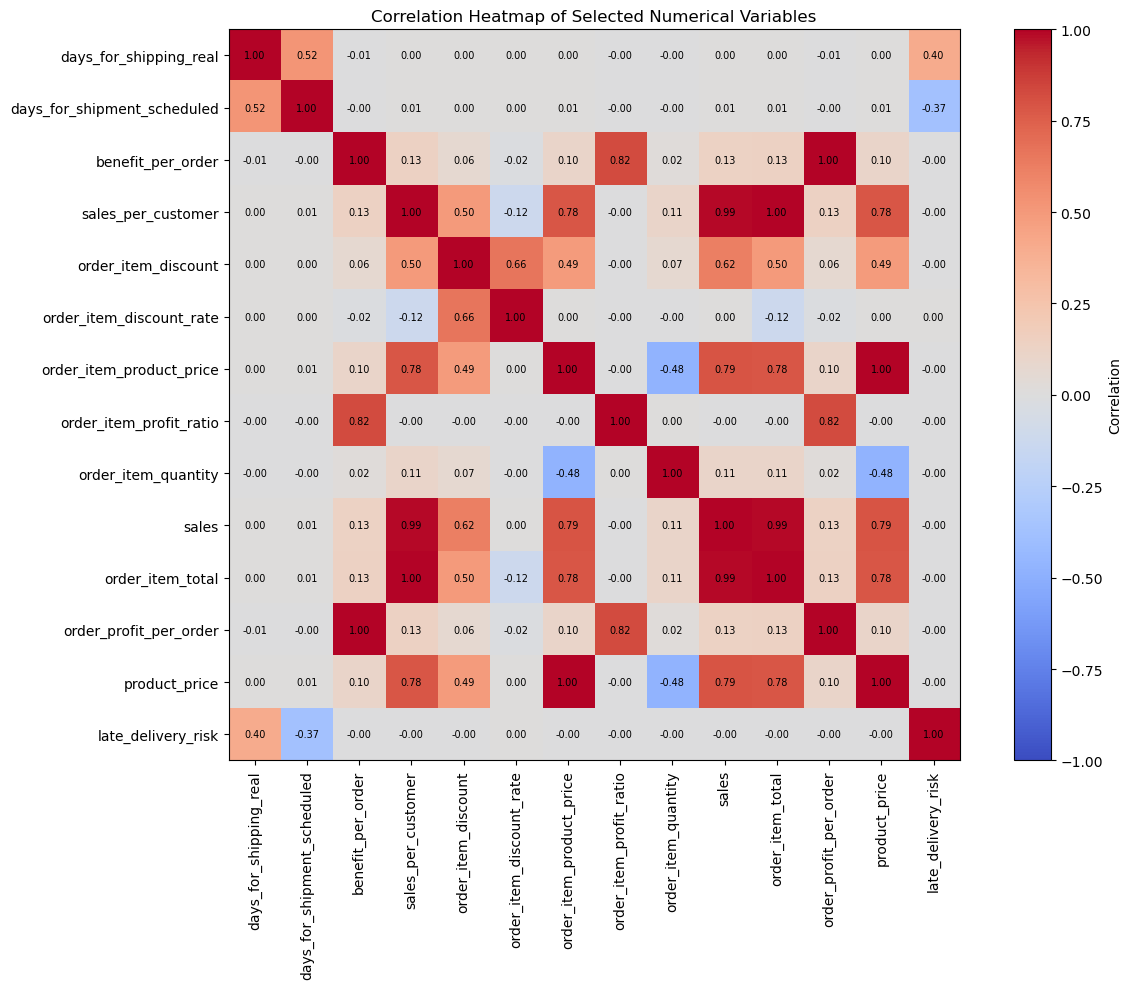

In [18]:
import numpy as np

fig, ax = plt.subplots(figsize=(13, 10))

im = ax.imshow(
    correlation_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

ax.set_xticks(np.arange(len(correlation_columns)))
ax.set_yticks(np.arange(len(correlation_columns)))

ax.set_xticklabels(correlation_columns, rotation=90)
ax.set_yticklabels(correlation_columns)

# Add correlation values inside each cell
for i in range(len(correlation_columns)):
    for j in range(len(correlation_columns)):
        ax.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=7
        )

fig.colorbar(im, ax=ax, label="Correlation")
ax.set_title("Correlation Heatmap of Selected Numerical Variables")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "numeric_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Correlation Interpretation

The following interpretation describes **order-item-weighted** results.

Several strong correlations are visible among the financial variables. `benefit_per_order` and `order_profit_per_order` have a correlation of 1.00, `sales_per_customer` and `order_item_total` have a correlation of 1.00, and `order_item_product_price` and `product_price` also have a correlation of 1.00. These relationships support the earlier observation that some variables may contain redundant information.

`sales` is also very strongly correlated with `sales_per_customer` and `order_item_total` (approximately 0.99). In addition, `benefit_per_order` and `order_item_profit_ratio` have a relatively strong positive correlation of approximately 0.82.

Among the variables examined, `late_delivery_risk` has a positive correlation of approximately 0.40 with `days_for_shipping_real` and a negative correlation of approximately -0.37 with `days_for_shipment_scheduled`. Most of the financial and order-item variables have correlations close to zero with the late-delivery target.

These correlations describe associations and do not establish causal relationships. In particular, `days_for_shipping_real` is a post-outcome variable and its correlation with `late_delivery_risk` must not be interpreted as evidence that it is an appropriate order-time predictive feature.

## 10. Outlier Review

Potential outliers are reviewed using the interquartile range (IQR) rule. Values below Q1 - 1.5 × IQR or above Q3 + 1.5 × IQR are flagged for descriptive review.

Being identified as a statistical outlier does not necessarily mean that an observation is incorrect. Outliers remain in the dataset unless there is evidence that they are invalid.

In [19]:
outlier_results = []

for column in analysis_numeric_columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ).sum()

    outlier_results.append({
        "variable": column,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": outlier_count,
        "outlier_percentage": (outlier_count / len(df)) * 100
    })

outlier_table = pd.DataFrame(outlier_results)

outlier_table.round(2)

,variable,lower_bound,upper_bound,outlier_count,outlier_percentage
0,days_for_shipping_real,-2.50,9.50,0,0.00
1,days_for_shipment_scheduled,-1.00,7.00,0,0.00
2,benefit_per_order,-79.70,151.50,18942,10.49
3,sales_per_customer,-110.15,461.93,1943,1.08
4,order_item_discount,-31.48,66.87,7537,4.18
5,order_item_discount_rate,-0.14,0.34,0,0.00
6,order_item_product_price,-174.99,424.98,2048,1.13
7,order_item_profit_ratio,-0.34,0.78,17300,9.58
8,order_item_quantity,-2.00,6.00,0,0.00
9,sales,-149.98,569.91,488,0.27


### Outlier Interpretation

The IQR review identifies the largest proportions of potential outliers in the profitability variables. Approximately 10.49% of observations are flagged for both `benefit_per_order` and `order_profit_per_order`, while approximately 9.58% are flagged for `order_item_profit_ratio`.

Smaller proportions of potential outliers appear in `order_item_discount` (4.18%), price-related variables (1.13%), `sales_per_customer` and `order_item_total` (1.08%), and `sales` (0.27%).

No IQR outliers are identified for the shipping-duration variables, discount rate, or order-item quantity.

These results are consistent with the skewness observed earlier, particularly for the profit-related variables. However, an extreme value is not necessarily an invalid value. For example, negative profit observations may represent genuine losses, while unusually large sales or discounts may represent legitimate high-value transactions.

Therefore, no observations are removed solely because they are identified as statistical outliers. Outliers remain unless there is evidence that they are invalid.

## 11. Key Findings and Limitations

### Key Findings

The original findings below are **order-item-weighted**; the unique-order shipping comparison in Section 6 gives each order equal weight.

- Late deliveries represent 54.83% of the observations, compared with 45.17% classified as not late.
- Actual shipping duration averages 3.50 days, compared with 2.93 scheduled days.
- 57.28% of observations have positive shipping delays, while 18.70% are exactly on schedule and 24.02% are completed faster than scheduled.
- Late observations have longer actual shipping durations and shorter scheduled shipping durations than non-late observations.
- Most financial and order-item variables show relatively small descriptive differences between late and non-late delivery groups.
- Several financial variables are strongly skewed and contain substantial extreme values, particularly the profitability measures.
- Several pairs of variables show perfect or near-perfect correlations, suggesting potential redundancy. Examples include `benefit_per_order` and `order_profit_per_order`, `sales_per_customer` and `order_item_total`, and `order_item_product_price` and `product_price`.
- Most financial variables have little linear correlation with `late_delivery_risk` in this descriptive analysis.

### Limitations and Leakage Considerations

Each order-item row receives equal weight. Orders containing more items therefore contribute more weight to shipping statistics, target percentages, group comparisons, and correlations. The original results do not estimate an equally weighted average across unique orders. Section 6 separately provides a unique-order shipping comparison after verifying within-order consistency; other analyses remain order-item-weighted.

The analysis is exploratory and identifies associations rather than causal relationships. Numerical differences between late and non-late observations should therefore not be interpreted as evidence that particular variables cause delivery outcomes.

`days_for_shipping_real` and the derived `shipping_delay_days` contain post-outcome information. They are useful for understanding historical delivery performance but are not appropriate order-time predictive features.

`order_id` and other identifier fields are structural variables rather than ordinary numerical features and were excluded from the main numerical descriptive and correlation analyses.

Potential outliers were retained because statistical extremeness alone does not establish that an observation is invalid. Further investigation would be required before removing or modifying unusual values.

No machine-learning models, train/test splits, resampling procedures, or predictive feature transformations were performed in this notebook.